<div style="text-align:center;">
  <h1 size=10>
    <b>MLOps PROJECT</b><br>
    <b></b>
  </h1>
</div>

<h2 style="text-align:center;">
Master's in Data Science and Advanced Analytics - NOVA IMS (25/26)
</h2>

**Group ??**
- Bárbara Franco (20250388)
- Inês Caetano (20221950)
- João Bernardo (20221889)
- Maria Carvalho (20221953)
- Maria Miguel Fonseca (20250380)

**GitHub repository: https://github.com/barbara-sousa-franco/MLOps_Project**

<font color='#2f94d7' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a>

- [1. Project Overview](#1)
- [2. Set Up & Import Libraries](#2)
- [3. Load Data](#3)
- [4. Metadata](#4)
- [5. Data Exploration](#5)
    - [5.1 Info](#5_1)
    - [5.2 Describe](#5_2)
    - [5.3 Duplicates](#5_3)
    - [5.4 Missing Values](#5_4)
    - [5.5 Unique Values](#5_5)
    - [5.6 Distinct Values](#5_6)
    - [5.7 Checking for Outliers](#5_7)
    - [5.8 Target Variable Analysis (Price)](#5_8)
    - [5.9 Data Quality & Impossible Values](#5_9)
        - [5.9.1 Investigating the Extreme Values Further](#5_9_1)
    - [5.10 Temporal Analysis (PublishDate)](#5_10)
    - [5.11 Relationships between Variables](#5_11)
    - [5.12 Categorical Association - Cramér's V](#5_12)

# <font color='#2f94d7' size=6>**1. Project Overview**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

# <font color='#2f94d7' size=6>**2. Set Up & Import Libraries**</font> <a class="anchor" id="2"></a>

[Back to TOC](#toc)

In [3]:
import sys
print(sys.executable)

C:\Users\35191\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
import re

ModuleNotFoundError: No module named 'pandas'

# <font color='#2f94d7' size=6>**3. Load Data**</font> <a class="anchor" id="3"></a>

[Back to TOC](#toc)

In [2]:
df_train = pd.read_csv('../data/01_raw/portugal_listings.csv')

/var/folders/s9/nfpy2jls4ps2k_p8lpjz6_yr0000gn/T/ipykernel_82540/3380079234.py:1: DtypeWarning: Columns (9,10,12,13,14,15,16,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv('../data/01_raw/portugal_listings.csv')


# <font color='#2f94d7' size=6>**4. Metadata**</font> <a class="anchor" id="4"></a>

[Back to TOC](#toc)

This dataset contains real estate listings scraped from a Portuguese property platform. Each row represents a single property listing, with information on price, location, type, energy rating, area, room counts, and other features. The goal of this EDA is to explore pricing patterns and property characteristics across the Portuguese real estate market.

| Feature | Description |
|---------|-------------|
| `Price` | Sale price of the property, in Euros (€). |
| `District` | District where the property is located (highest administrative level in Portugal). |
| `City` | Municipality (*concelho*) where the property is located. |
| `Town` | Parish or specific locality (*freguesia*) within the municipality. |
| `Type` | Type of property (e.g. Apartment, House, Garage, Land). |
| `EnergyCertificate` | Energy certificate rating per Portuguese standards (e.g. A+, A, B, B-, C, D, E, F, G). |
| `EnergyEfficiencyLevel` | Secondary/duplicate energy rating field, partially populated. To be reviewed against `EnergyCertificate`. |
| `GrossArea` | Gross private area of the property in m², including walls and areas of exclusive owner use. |
| `TotalArea` | Total area associated with the property in m², potentially including common areas or dependencies (garage, storage). |
| `LivingArea` | Interior livable area of the property in m², excluding walls and non-habitable spaces. |
| `LotSize` | Total land/plot area associated with the property in m². Mainly relevant for houses and land. |
| `BuiltArea` | Total built area of the property in m², including all structures built on the plot. |
| `TotalRooms` | Total number of rooms in the property (includes bedrooms, living rooms, and other habitable spaces). |
| `NumberOfBedrooms` | Number of bedrooms in the property. |
| `NumberOfWC` | Number of WCs (toilet rooms without bathtub/shower — toilet and sink only). |
| `NumberOfBathrooms` | Number of full bathrooms (with bathtub or shower). |
| `Floor` | Floor on which the property is located (e.g. Ground Floor, 1st Floor, Basement). |
| `Parking` | Number of parking spaces associated with the property. |
| `HasParking` | Whether the property has parking space(s). Derived from `Parking`. |
| `Garage` | Whether the property has an enclosed garage, distinct from a simple parking space. |
| `Elevator` | Whether the building has an elevator. |
| `ElectricCarsCharging` | Whether the property/building has an electric vehicle charger. |
| `ConservationStatus` | Conservation status of the property (e.g. New, Good condition, Needs renovation). |
| `ConstructionYear` | Year the property was built. |
| `PublishDate` | Date/time the listing was published on the platform. |

# <font color='#2f94d7' size=6>**5. Data Exploration**</font> <a class="anchor" id="5"></a>

[Back to TOC](#toc)

In [3]:
df_train.shape

(135536, 25)

In [4]:
df_train.head(10)

,Price,District,City,Town,Type,EnergyCertificate,GrossArea,TotalArea,Parking,HasParking,...,Elevator,ElectricCarsCharging,TotalRooms,NumberOfBedrooms,NumberOfWC,ConservationStatus,LivingArea,LotSize,BuiltArea,NumberOfBathrooms
0,780000.0,Vila Real,Valpaços,Carrazedo de Montenegro e Curros,Farm,NC,200.0,552450.0,0.0,False,...,False,NaN,NaN,NaN,NaN,NaN,120.0,NaN,NaN,0.0
1,223000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,81.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,81.0,NaN,NaN,2.0
2,228000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,108.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,108.0,NaN,NaN,2.0
3,250000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,114.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,114.0,NaN,NaN,0.0
4,250000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,114.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,114.0,NaN,NaN,2.0
5,250000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,NaN,115.0,1.0,True,...,True,NaN,2.0,NaN,NaN,NaN,115.0,NaN,NaN,2.0
6,2950000.0,Faro,Albufeira,Albufeira e Olhos de Água,Building,NC,465.0,265.0,0.0,False,...,False,NaN,NaN,NaN,NaN,NaN,406.0,NaN,NaN,0.0
7,165000.0,Faro,Castro Marim,Altura,Land,NC,NaN,960.0,3.0,True,...,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
8,9500.0,Faro,Albufeira,Albufeira e Olhos de Água,Apartment,NC,NaN,27.0,0.0,False,...,True,NaN,0.0,NaN,NaN,NaN,27.0,NaN,NaN,1.0
9,158000.0,Faro,Portimão,Portimão,Apartment,D,48.0,21953.0,1.0,True,...,True,NaN,1.0,NaN,NaN,NaN,42.0,NaN,NaN,2.0


In [5]:
df_train.tail(10)

,Price,District,City,Town,Type,EnergyCertificate,GrossArea,TotalArea,Parking,HasParking,...,Elevator,ElectricCarsCharging,TotalRooms,NumberOfBedrooms,NumberOfWC,ConservationStatus,LivingArea,LotSize,BuiltArea,NumberOfBathrooms
135526,77500.0,Vila Real,Montalegre,Salto,Apartment,NC,NaN,39.0,0.0,NaN,...,False,False,NaN,1.0,NaN,New,39.0,NaN,60.0,1.0
135527,1980000.0,Setúbal,Almada,Charneca de Caparica e Sobreda,House,B,NaN,220.0,1.0,NaN,...,False,False,5.0,4.0,1.0,New,206.0,1101.0,220.0,5.0
135528,537500.0,Setúbal,Alcácer do Sal,Alcácer do Sal (Santa Maria do Castelo e Santi...,Building,D,NaN,156.0,0.0,NaN,...,False,False,NaN,NaN,0.0,NaN,156.0,58.0,NaN,0.0
135529,395000.0,Setúbal,Alcochete,Alcochete,Apartment,D,NaN,232.0,0.0,NaN,...,True,False,NaN,4.0,NaN,Good condition,119.0,232.0,NaN,2.0
135530,990000.0,Setúbal,Almada,"Almada, Cova da Piedade, Pragal e Cacilhas",Building,NC,NaN,564.0,0.0,NaN,...,False,False,NaN,NaN,0.0,NaN,563.0,NaN,NaN,0.0
135531,130000.0,Setúbal,Palmela,Palmela,Land,NC,NaN,1189.0,0.0,NaN,...,False,False,NaN,NaN,0.0,NaN,NaN,1189.0,NaN,0.0
135532,45000.0,Viana do Castelo,Ponte de Lima,Labruja,House,NC,NaN,374.0,1.0,NaN,...,False,False,NaN,0.0,0.0,NaN,374.0,4370.0,NaN,0.0
135533,349900.0,Vila Real,Valpaços,Valpaços e Sanfins,House,F,NaN,188.0,1.0,NaN,...,False,False,NaN,3.0,1.0,NaN,190.0,18240.0,238.0,3.0
135534,50000.0,Vila Real,Alijó,Castedo e Cotas,House,NC,NaN,69.0,1.0,NaN,...,False,False,NaN,2.0,1.0,NaN,84.0,NaN,84.5,2.0
135535,35000.0,Vila Real,Valpaços,Algeriz,Land,NC,NaN,100.0,0.0,NaN,...,False,False,NaN,NaN,0.0,NaN,NaN,100.0,NaN,0.0


In [6]:
df_train.columns

Index(['Price', 'District', 'City', 'Town', 'Type', 'EnergyCertificate',
       'GrossArea', 'TotalArea', 'Parking', 'HasParking', 'Floor',
       'ConstructionYear', 'EnergyEfficiencyLevel', 'PublishDate', 'Garage',
       'Elevator', 'ElectricCarsCharging', 'TotalRooms', 'NumberOfBedrooms',
       'NumberOfWC', 'ConservationStatus', 'LivingArea', 'LotSize',
       'BuiltArea', 'NumberOfBathrooms'],
      dtype='object')

In [7]:
categorical_features = df_train.select_dtypes(include=['object']).columns
print("Categorical features:")
print(categorical_features)

Categorical features:
Index(['District', 'City', 'Town', 'Type', 'EnergyCertificate', 'HasParking',
       'Floor', 'EnergyEfficiencyLevel', 'PublishDate', 'Garage', 'Elevator',
       'ElectricCarsCharging', 'ConservationStatus'],
      dtype='object')


In [8]:
numeric_features = df_train.select_dtypes(include=['number']).columns
print("Numeric features:")
print(numeric_features)

Numeric features:
Index(['Price', 'GrossArea', 'TotalArea', 'Parking', 'ConstructionYear',
       'TotalRooms', 'NumberOfBedrooms', 'NumberOfWC', 'LivingArea', 'LotSize',
       'BuiltArea', 'NumberOfBathrooms'],
      dtype='object')


## <font color='#2f94d7' size=6>**5.1 Info**</font> <a class="anchor" id="5_1"></a>

[Back to TOC](#toc)

In [9]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135536 entries, 0 to 135535
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Price                  135236 non-null  float64
 1   District               135536 non-null  object 
 2   City                   135536 non-null  object 
 3   Town                   135534 non-null  object 
 4   Type                   135520 non-null  object 
 5   EnergyCertificate      135522 non-null  object 
 6   GrossArea              27638 non-null   float64
 7   TotalArea              127153 non-null  float64
 8   Parking                135342 non-null  float64
 9   HasParking             68215 non-null   object 
 10  Floor                  27929 non-null   object 
 11  ConstructionYear       88021 non-null   float64
 12  EnergyEfficiencyLevel  67289 non-null   object 
 13  PublishDate            29239 non-null   object 
 14  Garage                 67289 non-nul

`df_train.info()` confirms 135,536 rows and 25 columns (12 `float64`, 13 `object`).

- **Missing values are widespread**: columns like `GrossArea`, `HasParking`,
  `TotalRooms`, and `NumberOfBedrooms` already show high null rates, to be quantified
  per-column below.
- **`Type` includes non-residential categories** (e.g. Land): for these, nulls in
  `NumberOfBedrooms`/`BuiltArea` reflect that the feature doesn't apply, not that
  data is missing, so high null counts in room/building columns may partly
  reflect `Type`, not just data quality.
- **Near-complete columns** (>99.8% populated): `District`, `City`, `Elevator`,
  `EnergyCertificate`, `Type`, `Parking`, usable directly with minimal cleaning.
- **A likely shared-cause block**: `HasParking`, `EnergyEfficiencyLevel`, `Garage`,
  and `ElectricCarsCharging` all share a near-identical ~50% null rate, suggesting
  they may be missing on the same rows (e.g. different source/scrape batch) rather
  than independently. Investigated below.
- **Heavily missing (>70% null)**: `GrossArea`, `Floor`, `PublishDate`,
  `ConservationStatus`, `BuiltArea`, `LotSize`. Partly explained by `Type` (e.g.
  land has no `BuiltArea`), but `ConservationStatus` (86%) and `Floor` (79%) are
  sparse enough to suggest inconsistent capture at the source too.
- **Moderately missing**: `NumberOfBedrooms` (65%), `LotSize` (71%), `NumberOfWC`
  (58%), `TotalRooms` (46%), will need a deliberate per-feature strategy.
- **Nearly complete numerics**: `Price` (0.2%), `NumberOfBathrooms` (5%),
  `TotalArea` (6%), usable with minimal imputation.

Missingness is not uniform, likely correlated with `Type` and/or data source.
Both are checked explicitly below before deciding how to handle nulls.

(Note: `PublishDate` will be parsed to `datetime` later, not at this stage.)

## <font color='#2f94d7' size=6>**5.2 Describe**</font> <a class="anchor" id="5_2"></a>

[Back to TOC](#toc)

In [10]:
df_train[numeric_features].describe()

,Price,GrossArea,TotalArea,Parking,ConstructionYear,TotalRooms,NumberOfBedrooms,NumberOfWC,LivingArea,LotSize,BuiltArea,NumberOfBathrooms
count,1.352360e+05,2.763800e+04,1.271530e+05,135342.000000,88021.000000,73244.000000,47041.000000,57256.000000,1.049520e+05,3.958300e+04,2.661700e+04,128700.000000
mean,3.681374e+05,2.789733e+03,5.140780e+05,0.549667,1989.303825,3.229357,2.665823,0.430785,1.403037e+03,5.636939e+04,3.086621e+03,1.544025
std,3.804044e+06,1.153670e+05,1.722937e+08,0.839257,26.684309,10.516977,1.790474,1.016360,3.474597e+04,5.208474e+06,1.185137e+05,1.764637
min,1.000000e+00,-7.000000e+00,-7.196067e+06,0.000000,1900.000000,0.000000,0.000000,-15.000000,0.000000e+00,0.000000e+00,-1.000000e+00,-13.000000
25%,8.400000e+04,1.000000e+02,9.100000e+01,0.000000,1973.000000,2.000000,2.000000,0.000000,8.000000e+01,2.580000e+02,1.045700e+02,0.000000
50%,2.100000e+05,1.640000e+02,1.590000e+02,0.000000,1994.000000,3.000000,3.000000,0.000000,1.180000e+02,6.790000e+02,1.680000e+02,1.000000
75%,3.950000e+05,2.940000e+02,5.000000e+02,1.000000,2009.000000,4.000000,3.000000,1.000000,2.040000e+02,2.890000e+03,3.000000e+02,2.000000
max,1.380000e+09,1.275000e+07,6.142007e+10,3.000000,2025.000000,2751.000000,21.000000,59.000000,5.429000e+06,9.923010e+08,1.275000e+07,131.000000


In [11]:
df_train[categorical_features].describe()

,District,City,Town,Type,EnergyCertificate,HasParking,Floor,EnergyEfficiencyLevel,PublishDate,Garage,Elevator,ElectricCarsCharging,ConservationStatus
count,135536,135536,135534,135520,135522,68215,27929,67289,29239,67289,135504,67289,19292
unique,27,275,2263,21,12,2,19,11,27832,2,2,2,6
top,Lisboa,Lisboa,Paranhos,Apartment,NC,False,Ground Floor,NC,2024-09-04 13:59:28.870,False,False,False,New
freq,31351,8396,2228,47378,61387,37370,6973,31316,6,55594,102567,60863,6688


**Numeric features** confirm issues already flagged, now with exact figures:

- **Impossible negative values**: `GrossArea` (min -7), `TotalArea` (min -7.2M),
  `BuiltArea` (min -1), `NumberOfWC` (min -15). These are data errors to clean, not outliers
  to cap.
- **Extreme upper outliers**: `TotalArea` max 61.4 billion, `LotSize` max ~992M,
  `BuiltArea` max ~12.75M, `Price` max 1.38 billion, `TotalRooms` max 2751. The huge
  gap between the 75th percentile and the max in every case confirms isolated
  extreme outliers rather than natural skew (will need filtering before
  visualization).
- **Central tendency looks reasonable once outliers are set aside**: median `Price`
  is €210,000, median `TotalArea`/`LivingArea` are realistic (159 m² / 118 m²),
  median `ConstructionYear` is 1994.

**Categorical features**:

- **High-cardinality location fields**: `Town` (2,263 unique) and `City` (275
  unique) are too granular for direct use; `District` (27 unique) is a better
  candidate for initial geographic analysis.
- **`Lisboa` dominates** both `District` and `City` counts. Is worth checking if it
  skews price/area distributions before drawing national conclusions.
- **`Apartment` dominates `Type`** (~35% of non-null rows), confirming an
  apartment-heavy dataset.
- **`NC` (no certificate) is the most common `EnergyCertificate` value** — more
  listings lack a rating than have any single grade.
- **The ~50% null block is confirmed boolean-like and imbalanced**: `HasParking`,
  `EnergyEfficiencyLevel`, `Garage`, `ElectricCarsCharging` share the same non-null
  count, and within populated rows, `False`/`NC` dominate heavily.
- **`ConservationStatus`**: only 6 categories but 86% null, too sparse to use
  without imputation or exclusion.

Beyond missingness, the *populated* data is often skewed toward one dominant
category (Lisboa, Apartment, NC, False), worth keeping in mind for later
visualization and imputation.

## <font color='#2f94d7' size=6>**5.3 Duplicates**</font> <a class="anchor" id="5_3"></a>

[Back to TOC](#toc)

In [12]:
df_train.duplicated().sum()

np.int64(8913)

In [13]:
print("The percentage of duplicated that would be deleted is: {:.2f}%".format(df_train.duplicated().sum() / len(df_train) * 100))

The percentage of duplicated that would be deleted is: 6.58%


`df_train.duplicated().sum()` finds **8,913 exact duplicate rows** (6.58% of the
dataset). This is a meaningful chunk, before deciding to drop them, it's worth
checking whether these are true duplicate listings (e.g. the same property scraped
twice) or just properties that happen to share identical values across all 25
columns by coincidence (more plausible for cheap, common listings like small land
plots with no extra features). Decision deferred to the cleaning stage.

In [14]:
# Are duplicates concentrated in certain Types? (e.g. cheap/simple listings like Land, Garage)
print(df_train[df_train.duplicated()]['Type'].value_counts())
print()
print("As % of each type's total count:")
print((df_train[df_train.duplicated()]['Type'].value_counts() / df_train['Type'].value_counts() * 100).sort_values(ascending=False))

Type
Apartment              3379
Land                   2308
House                  2194
Store                   270
Farm                    126
Warehouse               102
Building                 91
Garage                   91
Transfer of lease        57
Other - Commercial       51
Other - Residential      43
Industrial               41
Storage                  37
Investment               33
Office                   29
Duplex                   22
Studio                   21
Hotel                    12
Estate                    4
Manor                     1
Name: count, dtype: int64

As % of each type's total count:
Type
Studio                 24.137931
Storage                18.226601
Manor                  14.285714
Investment             12.941176
Garage                  9.323770
Industrial              9.297052
Hotel                   7.453416
Land                    7.248061
Other - Residential     7.178631
Apartment               7.132002
Warehouse               7.063712
Other -

In [15]:
# Are duplicates concentrated in low-price / low-info listings?
print("Price stats for duplicated rows:")
print(df_train[df_train.duplicated()]['Price'].describe())
print()
print("Price stats for non-duplicated rows:")
print(df_train[~df_train.duplicated()]['Price'].describe())

Price stats for duplicated rows:
count    8.896000e+03
mean     3.318268e+05
std      4.608208e+05
min      5.000000e+02
25%      7.500000e+04
50%      2.350000e+05
75%      4.000000e+05
max      1.100000e+07
Name: Price, dtype: float64

Price stats for non-duplicated rows:
count    1.263400e+05
mean     3.706942e+05
std      3.933782e+06
min      1.000000e+00
25%      8.500000e+04
50%      2.100000e+05
75%      3.900000e+05
max      1.380000e+09
Name: Price, dtype: float64


In [16]:
# Check duplicates excluding PublishDate (in case the same listing was re-scraped on different dates)
cols_no_date = [c for c in df_train.columns if c != 'PublishDate']
dupes_ignoring_date = df_train.duplicated(subset=cols_no_date).sum()
print(f"Duplicates when ignoring PublishDate: {dupes_ignoring_date} ({dupes_ignoring_date/len(df_train)*100:.2f}%)")

Duplicates when ignoring PublishDate: 11333 (8.36%)


**Handling Duplicates**

Evidence on the cause of duplication is mixed:

- Excluding `PublishDate` only raises duplicates from 6.65% to 8.36%, too small an
  increase to support "same listing, re-scraped on a different date" as the main
  driver.
- Duplicated rows skew toward lower, less variable prices (mean €331,827, std
  €460,821) than non-duplicated rows (mean €370,694, std €3,933,782), consistent
  with simple, low-information listings (small land plots, basic studios) coinciding
  by chance across all 25 columns.
- Some duplicate clusters (e.g. several near-identical Albufeira apartment listings)
  look like the same unit or development listed multiple times, rather than
  coincidence.

Without a unique property ID, these two causes can't be fully separated. Given that
(a) removing exact duplicates never discards genuinely distinct information, by
definition two identical rows carry the same information once, and (b) the
resulting dataset (126,525 rows, 93.35% of the original) remains large and
representative, we proceed with `df_train.drop_duplicates()`, keeping the first
occurrence.

## <font color='#2f94d7' size=6>**5.4 Missing Values**</font> <a class="anchor" id="5_4"></a>

[Back to TOC](#toc)

In [17]:
print(df_train.isnull().sum())
print()
print(f"Total missing values: {df_train.isna().sum().sum()}")

Price                       300
District                      0
City                          0
Town                          2
Type                         16
EnergyCertificate            14
GrossArea                107898
TotalArea                  8383
Parking                     194
HasParking                67321
Floor                    107607
ConstructionYear          47515
EnergyEfficiencyLevel     68247
PublishDate              106297
Garage                    68247
Elevator                     32
ElectricCarsCharging      68247
TotalRooms                62292
NumberOfBedrooms          88495
NumberOfWC                78280
ConservationStatus       116244
LivingArea                30584
LotSize                   95953
BuiltArea                108919
NumberOfBathrooms          6836
dtype: int64

Total missing values: 1237923


In [18]:
print("The percentage of missing values that would be deleted is: {:.2f}%".format(df_train.isnull().sum().sum() / df_train.size * 100))

The percentage of missing values that would be deleted is: 36.53%


Across the full dataset, **36.55% of all cells are missing** (1,238,383 out of
135,536 × 25). This rules out any single blanket rule (e.g.
dropping rows with any null would discard nearly the entire dataset); missing data
needs a feature-by-feature strategy. We start with the per-column breakdown, then
investigate two specific patterns: a block of columns that appear to share a cause,
and the role of property `Type`.

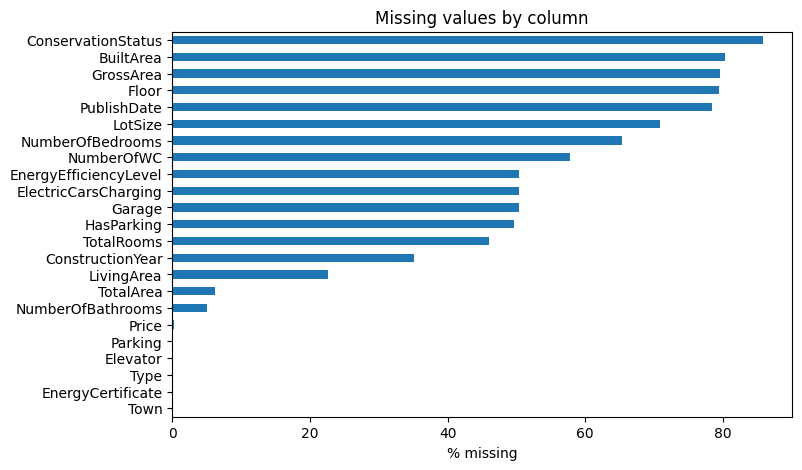

In [19]:
miss = (df_train.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]
plt.figure(figsize=(8, 5))
miss.plot.barh()
plt.gca().invert_yaxis()
plt.xlabel('% missing'); plt.title('Missing values by column'); plt.show()

**Near-complete**: `District`, `City`, `Elevator`, `EnergyCertificate`,
`Type`, `Parking`.

**Heaviest nulls** (>70%): `ConservationStatus`, `BuiltArea`, `GrossArea`, `Floor`,
`PublishDate`, `LotSize`.

**Moderate nulls**: `NumberOfBedrooms`, `NumberOfWC`, `TotalRooms`.

**Nearly complete numerics**: `Price`, `NumberOfBathrooms`, `TotalArea`.

In [20]:
block_cols = ['HasParking', 'EnergyEfficiencyLevel', 'Garage', 'ElectricCarsCharging']
null_masks = df_train[block_cols].isnull()

null_counts_per_row = null_masks.sum(axis=1)
print(null_counts_per_row.value_counts().sort_index())

print("\nNull correlation matrix:")
print(null_masks.astype(int).corr())

1    67289
3    68215
4       32
Name: count, dtype: int64

Null correlation matrix:
                       HasParking  EnergyEfficiencyLevel    Garage  \
HasParking               1.000000              -0.999528 -0.999528   
EnergyEfficiencyLevel   -0.999528               1.000000  1.000000   
Garage                  -0.999528               1.000000  1.000000   
ElectricCarsCharging    -0.999528               1.000000  1.000000   

                       ElectricCarsCharging  
HasParking                        -0.999528  
EnergyEfficiencyLevel              1.000000  
Garage                             1.000000  
ElectricCarsCharging               1.000000  


`HasParking`, `EnergyEfficiencyLevel`, `Garage`, and `ElectricCarsCharging` share
a similar ~50% null rate. Checking whether their nulls fall on the same rows:

- **Every row falls into exactly one of three buckets**: `HasParking` null with
  the other 3 populated (67,289 rows), `HasParking` populated with the other 3
  null (68,215 rows), or all 4 null (32 rows). No other combination occurs.
- **Pairwise null correlation confirms it**: `EnergyEfficiencyLevel`, `Garage`,
  and `ElectricCarsCharging` correlate at 1.000 with each other, and at -0.9995
  with `HasParking`.
- **Conclusion**: two complementary data sources, not one shared cause,
  `HasParking` comes from one source, the other three from another, with almost
  no listing covered by both.

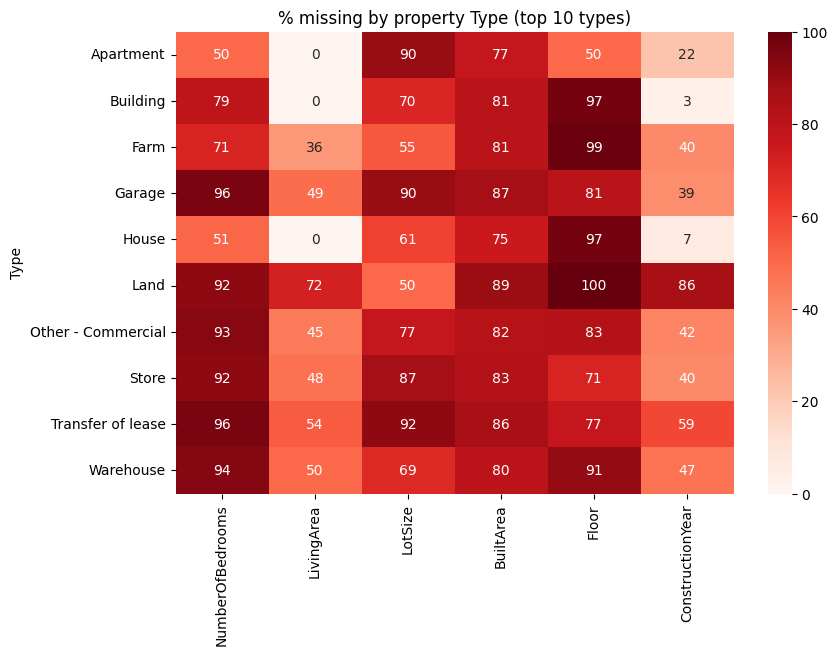

In [21]:
cols = ['NumberOfBedrooms', 'LivingArea', 'LotSize', 'BuiltArea', 'Floor', 'ConstructionYear']
top_types = df_train['Type'].value_counts().head(10).index
miss_by_type = (df_train[df_train['Type'].isin(top_types)]
                .groupby('Type')[cols]
                .apply(lambda g: g.isna().mean() * 100)
                .round(0))

plt.figure(figsize=(9, 6))
sns.heatmap(miss_by_type, annot=True, fmt='.0f', cmap='Reds')
plt.title('% missing by property Type (top 10 types)'); plt.show()

The heatmap shows missingness is also shaped by property `Type`, not just by data
source: `LivingArea` is 0% missing for `Apartment`/`House`/`Building` but 72%
missing for `Land` (no livable area by definition), and `NumberOfBedrooms` follows
a similar pattern for `Land`/`Garage`/`Warehouse`. So null rates reflect two
separate causes: feature relevance to the property type, and which data source
covered the listing, and imputation should account for both.

## <font color='#2f94d7' size=6>**5.5 Unique Values**</font> <a class="anchor" id="5_5"></a>

[Back to TOC](#toc)

In [22]:
for column in df_train.columns:
    unique_values = df_train[column].unique()
    print(f"Unique values on the column '{column}': {unique_values}")
    print('-----------------------------------')
    print('')


Unique values on the column 'Price': [780000. 223000. 228000. ... 890200. 912500. 605500.]
-----------------------------------

Unique values on the column 'District': ['Vila Real' 'Faro' 'Leiria' 'Porto' 'Lisboa' 'Guarda' 'Viseu' 'Setúbal'
 'Coimbra' 'Castelo Branco' 'Ilha Terceira' 'Beja' 'Santarém' 'Aveiro'
 'Évora' 'Braga' 'Ilha de São Miguel' 'Portalegre' 'Bragança'
 'Viana do Castelo' 'Ilha da Madeira' 'Ilha de Porto Santo'
 'Ilha de Santa Maria' 'Ilha de São Jorge' 'Z - Fora de Portugal'
 'Ilha do Faial' 'Ilha das Flores']
-----------------------------------

Unique values on the column 'City': ['Valpaços' 'São Brás de Alportel' 'Albufeira' 'Castro Marim' 'Portimão'
 'Loulé' 'Vila do Bispo' 'Olhão' 'Faro' 'Lagos' 'Peniche'
 'Vila Real de Santo António' 'Alcoutim' 'Lagoa (Algarve)' 'Silves'
 'Aljezur' 'Tavira' 'Porto' 'Monchique' 'Sintra' 'Seia'
 'Paços de Ferreira' 'Manteigas' 'Figueira de Castelo Rodrigo' 'Tondela'
 'Trancoso' 'Gouveia' 'Vila Nova de Foz Côa' 'Guarda' 'Almeida'

`unique()` confirms earlier findings and cleaning tasks:

- **`Type`**: 21 categories + `nan`, matching `describe()`.
- **`EnergyCertificate`**: 4 ways of saying "no rating" (`'NC'`, `'Not available'`,
  `'No Certificate'`, `nan`) needs consolidating.
- **`District`**: includes island groups (`'Ilha da Madeira'`, `'Ilha de São Miguel'`,
  etc.) and `'Z - Fora de Portugal'` (outside Portugal) alongside mainland districts,
  decide whether to keep/group/exclude based on analysis scope.
- **`Floor`**: confirmed categorical, 19 values (numbered floors, Basement/Basement
  Level, Attic, Mezzanine, Duplex, Triplex, Service Floor).
- **`ConstructionYear`**: clean range, 1900–2025, 125 distinct years.
- **`TotalRooms`**: 2751 is an isolated outlier (next highest is 100), confirmed
  data error.
- **Negative values confirmed**: `NumberOfWC` min -15, `NumberOfBathrooms` min -1
  and -13, impossible, need correction.
- **`PublishDate` is mostly well-formed**: format `YYYY-MM-DD HH:MM:SS.ffffff`
  (e.g. `'2024-10-18 16:35:08.843'`). Analysed further below.
- **`ConservationStatus`**: 6 clean categories, as found earlier.

## <font color='#2f94d7' size=6>**5.6 Distinct Values**</font> <a class="anchor" id="5_6"></a>

[Back to TOC](#toc)

`value_counts()` is only informative on columns with a limited set of possible
values. We split the numeric features into **discrete** (few distinct values, e.g.
`TotalRooms`) and **continuous** (thousands of distinct values, e.g. `Price`), and
analyze each differently, plus the **categorical** features separately.

In [23]:
# Categorical features — value_counts() to see frequency distribution per category
categorical_features = [
    'District',
    'City',
    'Town',
    'Type',
    'EnergyCertificate',
    'HasParking',
    'Floor',
    'EnergyEfficiencyLevel',
    'Garage',
    'Elevator',
    'ElectricCarsCharging',
    'ConservationStatus'
]

for column in categorical_features:
    count_values = df_train[column].value_counts()
    print(f"The number of the distinct values in the column '{column}' is: \n{count_values}")
    print('-----------------------------------')
    print('')

The number of the distinct values in the column 'District' is: 
District
Lisboa                  31351
Porto                   22681
Setúbal                 11579
Braga                   11445
Faro                     8943
Coimbra                  7622
Aveiro                   7439
Leiria                   7378
Santarém                 7044
Castelo Branco           5189
Viana do Castelo         3718
Évora                    2404
Vila Real                2273
Portalegre               1952
Guarda                   1469
Beja                     1286
Bragança                 1254
Ilha de Santa Maria       249
Viseu                      55
Ilha de São Miguel         55
Ilha de Porto Santo        47
Ilha Terceira              42
Z - Fora de Portugal       42
Ilha da Madeira            16
Ilha de São Jorge           1
Ilha do Faial               1
Ilha das Flores             1
Name: count, dtype: int64
-----------------------------------

The number of the distinct values in the column 'City'

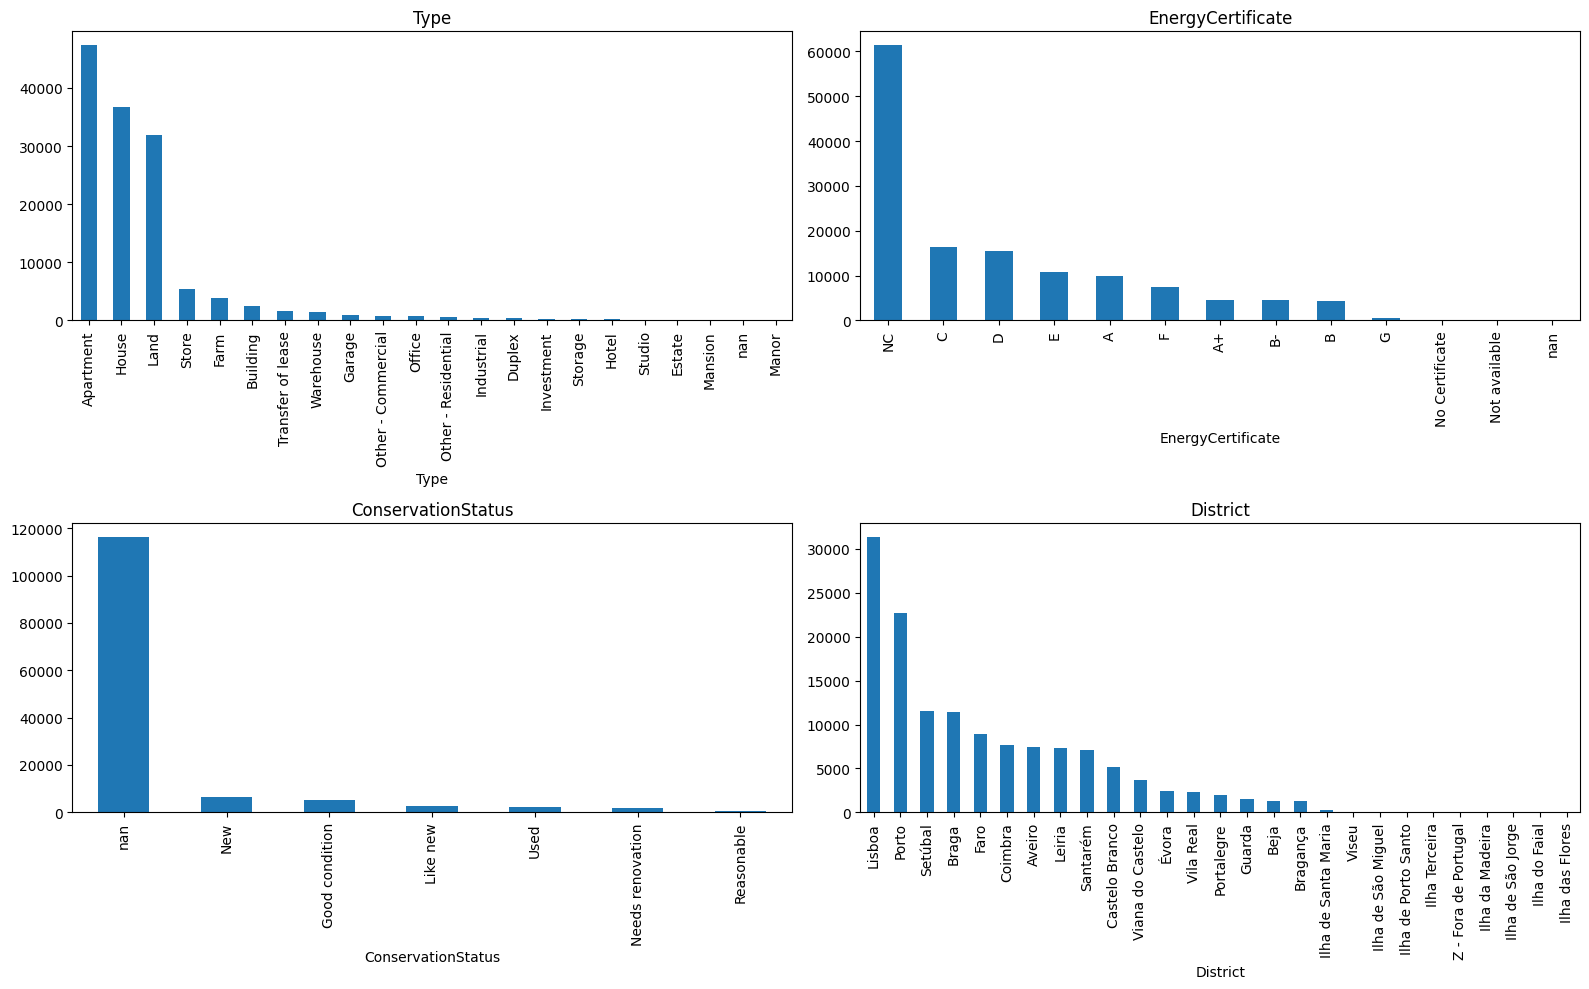

In [24]:
# Low-cardinality categoricals -> bar charts
plot_cols = ['Type', 'EnergyCertificate', 'ConservationStatus', 'District']
fig, ax = plt.subplots(2, 2, figsize=(16, 10))
for a, c in zip(ax.flat, plot_cols):
    df_train[c].value_counts(dropna=False).plot.bar(ax=a)
    a.set_title(c)
plt.tight_layout(); plt.show()

**Categorical Value Counts**

- **`District`**: Lisboa (31,351) and Porto (22,681) dominate. `Viseu` has only
  55 listings.
- **`City`/`Town`**: confirmed long-tail cardinality (many single-listing towns),
  `District` remains the more usable geographic feature.
- **`Type`**: Apartment, House, and Land dominate; niche types (`Manor`: 7,
  `Mansion`: 33) too sparse for standalone analysis.
- **`EnergyCertificate`**: `NC` dominates (~49% of non-null rows). "No rating" is
  split across 3 labels (`NC`, `No Certificate`, `Not available`), maybe should be merged.
- **`EnergyEfficiencyLevel`**: mirrors `EnergyCertificate`'s shape almost exactly,
  reinforcing it's a partial duplicate.
- **Booleans skew False**: `Garage`, `Elevator`, `ElectricCarsCharging` are heavily
  imbalanced; `HasParking` is closer to even.
- **`ConservationStatus`**: skews positive (`New`, `Good condition` most common),
  despite 86% being null.

In [25]:
# High-cardinality geography -> top 10 only
for c in ['City', 'Town']:
    print(f'Top 10 {c}:')
    print(df_train[c].value_counts().head(10), '\n')

Top 10 City:
City
Lisboa               8396
Sintra               5527
Porto                5446
Vila Nova de Gaia    4281
Cascais              3236
Braga                2625
Oeiras               2251
Coimbra              2206
Loures               2076
Guimarães            1996
Name: count, dtype: int64 

Top 10 Town:
Town
Paranhos                                                           2228
Cascais e Estoril                                                  1459
Albufeira e Olhos de Água                                          1433
Cedofeita, Santo Ildefonso, Sé, Miragaia, São Nicolau e Vitória    1069
Portimão                                                           1054
Quarteira                                                           889
Canidelo                                                            858
Algés, Linda-a-Velha e Cruz Quebrada-Dafundo                        851
Montijo e Afonsoeiro                                                768
Arroios                     

Zooming into the head of the long tail confirmed above: **`City`** is led by
Lisboa (8,396), Sintra (5,527), and Porto (5,446); **`Town`** is led by `Paranhos`
(2,228, a Porto parish), `Cascais e Estoril` (1,459), and `Albufeira e Olhos de
Água` (1,433). These are the natural candidates to keep as standalone categories
if less frequent locations are grouped into an "Other" bucket later.

In [26]:
# Discrete numeric features — finite set of meaningful values, suited to value_counts()
discrete_numeric_features = [
    'Parking',
    'TotalRooms',
    'NumberOfBedrooms',
    'NumberOfWC',
    'NumberOfBathrooms',
    'ConstructionYear'
]

for column in discrete_numeric_features:
    count_values = df_train[column].value_counts()
    print(f"The number of the distinct values in the column '{column}' is: \n{count_values}")
    print('-----------------------------------')
    print('')

The number of the distinct values in the column 'Parking' is: 
Parking
0.0    84580
1.0    34413
2.0     9067
3.0     7282
Name: count, dtype: int64
-----------------------------------

The number of the distinct values in the column 'TotalRooms' is: 
TotalRooms
3.0       20937
2.0       15293
4.0       12535
0.0        6916
1.0        5665
5.0        5258
6.0        2531
7.0        1216
8.0         812
9.0         451
10.0        439
12.0        266
11.0        206
14.0        106
15.0        106
13.0         97
21.0         69
16.0         60
18.0         43
17.0         39
20.0         39
19.0         28
22.0         13
30.0         10
26.0          9
23.0          9
25.0          9
24.0          7
28.0          6
33.0          6
32.0          5
35.0          4
27.0          4
31.0          4
36.0          4
44.0          3
53.0          3
29.0          3
37.0          3
49.0          2
100.0         2
70.0          2
80.0          2
97.0          2
51.0          2
40.0          2
3

**Discrete Numeric Value Counts**

- **`Parking`**: 0 dominates (84,580), then 1 (34,413); 2–3 are rare.
- **`TotalRooms`**: peaks at 3 (20,937) and 2 (15,293); confirms 2751 as a single
  isolated outlier.
- **`NumberOfBedrooms`**: peaks at 3 (14,918) and 2 (13,402); a small bump at 21
  bedrooms (63 occurrences) is suspicious, worth checking as a possible error.
- **`NumberOfWC`** and **`NumberOfBathrooms`**: heavily concentrated at 0–2, long
  tail of outliers, including the negative values found earlier.
- **`ConstructionYear`**: 2023 (5,912) is the most common year, but **1937 is
  oddly frequent too (4,980)**, far above neighboring years.

In [27]:
# Continuous area/price features — check for suspicious zero values instead of value_counts()
continuous_features = ['Price', 'GrossArea', 'TotalArea', 'LivingArea', 'LotSize', 'BuiltArea']

for column in continuous_features:
    zero_count = (df_train[column] == 0).sum()
    null_count = df_train[column].isnull().sum()
    total = len(df_train)
    print(f"{column}: {zero_count} zeros ({zero_count/total*100:.2f}%), {null_count} nulls ({null_count/total*100:.2f}%)")

Price: 0 zeros (0.00%), 300 nulls (0.22%)
GrossArea: 329 zeros (0.24%), 107898 nulls (79.61%)
TotalArea: 926 zeros (0.68%), 8383 nulls (6.19%)
LivingArea: 400 zeros (0.30%), 30584 nulls (22.57%)
LotSize: 626 zeros (0.46%), 95953 nulls (70.80%)
BuiltArea: 242 zeros (0.18%), 108919 nulls (80.36%)


Zero counts are low across the board (under 1% in every column), so the "zeros as
disguised missing data" concern raised earlier is **not significant**, these are
likely genuine small/zero areas (e.g. land with no built structure), not hidden
nulls. The real gap is null rate: `BuiltArea` (80.36%), `GrossArea` (79.61%), and
`LotSize` (70.80%) remain the most incomplete; `Price` (0.22%) and `TotalArea`
(6.19%) are nearly complete.

## <font color='#2f94d7' size=6>**5.7 Checking for Outliers**</font> <a class="anchor" id="5_7"></a>

[Back to TOC](#toc)

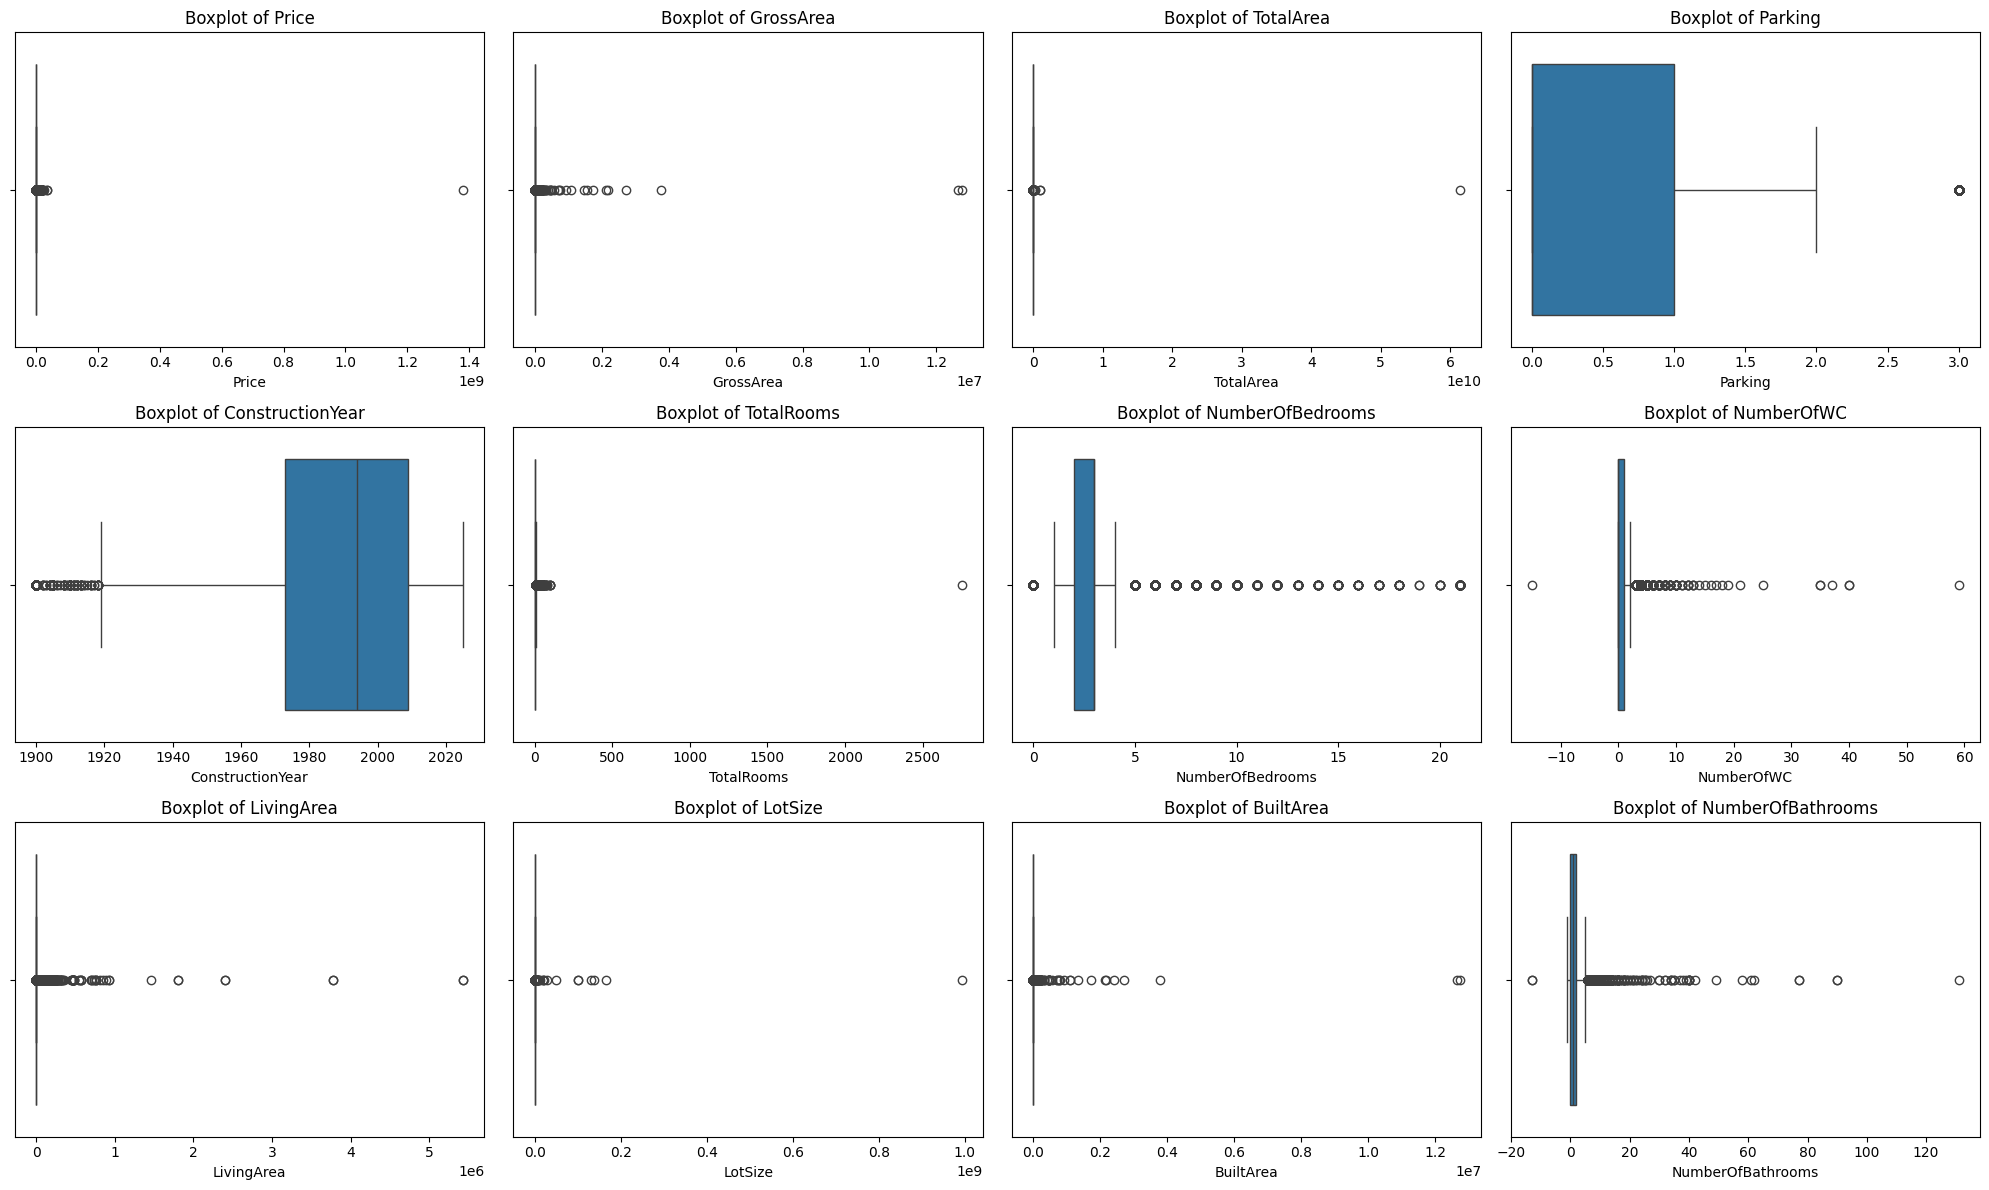

In [28]:
# see the boxplot of the numeric features
n_cols = 4
n_rows = -(-len(numeric_features) // n_cols)  # ceiling division

plt.figure(figsize=(20, n_rows * 4))
for i, column in enumerate(numeric_features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df_train[column])
    plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.show()

In [29]:
# check the index of the max of each numeric feature
for column in numeric_features:
    max_index = df_train[column].idxmax()
    print(f"The index of the max value in the column '{column}' is: {max_index}")

The index of the max value in the column 'Price' is: 58787
The index of the max value in the column 'GrossArea' is: 14782
The index of the max value in the column 'TotalArea' is: 73736
The index of the max value in the column 'Parking' is: 7
The index of the max value in the column 'ConstructionYear' is: 129201
The index of the max value in the column 'TotalRooms' is: 87191
The index of the max value in the column 'NumberOfBedrooms' is: 70399
The index of the max value in the column 'NumberOfWC' is: 94955
The index of the max value in the column 'LivingArea' is: 15329
The index of the max value in the column 'LotSize' is: 79564
The index of the max value in the column 'BuiltArea' is: 73400
The index of the max value in the column 'NumberOfBathrooms' is: 135169


The boxplots make the earlier findings visible: in almost every continuous column
(`Price`, `GrossArea`, `TotalArea`, `LivingArea`, `LotSize`, `BuiltArea`), the box
itself is compressed into a thin line near 0, with one or a few extreme points
stretching the axis out to millions or billions and confirming these are isolated
errors, not a naturally long-tailed distribution. `ConstructionYear` and `Parking`
look reasonable by comparison, with proper boxes and a tighter spread. `NumberOfWC`
and `NumberOfBathrooms` clearly show the negative outliers found earlier (down to
-15 and -13).

Checking the row index behind each column's maximum value shows they're spread
across **11 distinct rows** for 12 numeric columns (`Parking` and one other column
share a max-value row), i.e. these extreme outliers are not all coming from one
single corrupted row, but from a handful of different listings, each extreme in a
different feature. 

In [43]:
# IQR-based outlier detection across numeric features
numeric_cols = ['Price', 'GrossArea', 'TotalArea', 'LivingArea', 'LotSize', 'BuiltArea',
                'TotalRooms', 'NumberOfBedrooms', 'NumberOfBathrooms', 'NumberOfWC',
                'Parking', 'ConstructionYear']

iqr_summary = []

for col in numeric_cols:
    data = df_train[col].dropna()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    n_outliers = ((data < lower) | (data > upper)).sum()
    pct_outliers = n_outliers / len(data) * 100

    iqr_summary.append({
        'Column': col,
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outliers (n)': n_outliers,
        'Outliers (%)': round(pct_outliers, 2)
    })

iqr_df = pd.DataFrame(iqr_summary).sort_values('Outliers (%)', ascending=False)
print(iqr_df.to_string(index=False))

           Column       Q1       Q3       IQR  Lower Bound  Upper Bound  Outliers (n)  Outliers (%)
 NumberOfBedrooms     2.00      3.0      1.00         0.50         4.50          8368         17.79
        TotalArea    91.00    500.0    409.00      -522.50      1113.50         21553         16.95
          LotSize   258.00   2890.0   2632.00     -3690.00      6838.00          5578         14.09
       LivingArea    80.00    204.0    124.00      -106.00       390.00         11967         11.40
        BuiltArea   104.57    300.0    195.43      -188.58       593.14          3008         11.30
        GrossArea   100.00    294.0    194.00      -191.00       585.00          2980         10.78
            Price 84000.00 395000.0 311000.00   -382500.00    861500.00         10589          7.83
          Parking     0.00      1.0      1.00        -1.50         2.50          7282          5.38
       TotalRooms     2.00      4.0      2.00        -1.00         7.00          2893          3.95


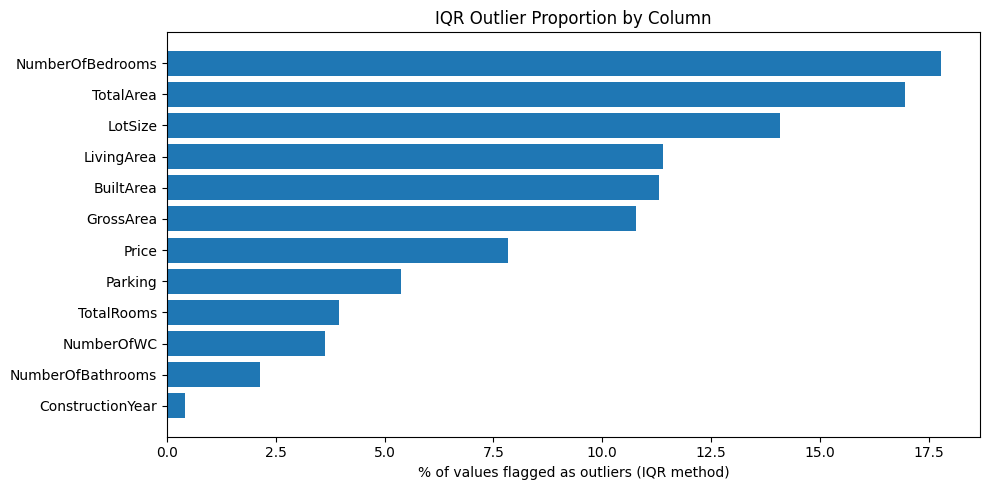

In [44]:
plt.figure(figsize=(10, 5))
plt.barh(iqr_df['Column'], iqr_df['Outliers (%)'])
plt.xlabel('% of values flagged as outliers (IQR method)')
plt.title('IQR Outlier Proportion by Column')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The standard 1.5×IQR rule across numeric columns complements the domain thresholds
used earlier:

- **`NumberOfBedrooms` has the highest rate (17.79%)** — not due to corrupt data,
  but a narrow IQR (Q1=2, Q3=3) that tightly bounds "normal" (0.5–4.5), flagging
  any 5+ bedroom property even if plausible.
- **Area columns remain heavily flagged** (`TotalArea` 16.95%, `LotSize` 14.09%,
  `LivingArea` 11.40%, `BuiltArea` 11.30%, `GrossArea` 10.78%), consistent with
  the extreme corrupt values already confirmed via boxplots and domain thresholds.
- **`Price`** (7.83%) and **`Parking`** (5.38%) are moderately flagged.
- **`ConstructionYear`** has the lowest rate (0.41%), confirms it's the cleanest
  numeric column, as found throughout.

**Takeaway**: IQR reinforces known corruption in area/price columns, but over-flags
narrow-range count columns (`NumberOfBedrooms`, `NumberOfWC`, `TotalRooms`) where
the typical range is small. Domain thresholds (e.g. `NumberOfBedrooms > 20`) remain
more reliable for these; IQR is a secondary signal, not a standalone removal rule.

In [ ]:
# Distribuição por coluna com threshold IQR marcado
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    s = df_train[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    # clip para visualização (99.5p) para não comprimir o histograma
    clip = s.quantile(0.995)
    s_clipped = s.clip(upper=clip)

    axes[i].hist(s_clipped, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].axvline(upper, color='red', linestyle='--', linewidth=1.2, label=f'IQR upper: {upper:,.0f}')
    if lower > s.min():
        axes[i].axvline(lower, color='orange', linestyle='--', linewidth=1.2, label=f'IQR lower: {lower:,.0f}')
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

plt.suptitle('Distribuições com thresholds IQR (histograma clipado ao p99.5 para legibilidade)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## <font color='#2f94d7' size=6>**5.8 Target Variable Analysis (Price)**</font> <a class="anchor" id="5_8"></a>

[Back to TOC](#toc)

In [30]:
price = df_train['Price']
print(price.describe())
print('\nSkew    :', round(price.skew(), 2))
print('Kurtosis:', round(price.kurt(), 2))
print('Price <= 1 EUR     :', int((price <= 1).sum()))
print('Price < 5 000 EUR  :', int((price < 5_000).sum()))
print('Price > 5 000 000  :', int((price > 5_000_000).sum()))

count    1.352360e+05
mean     3.681374e+05
std      3.804044e+06
min      1.000000e+00
25%      8.400000e+04
50%      2.100000e+05
75%      3.950000e+05
max      1.380000e+09
Name: Price, dtype: float64

Skew    : 352.81
Kurtosis: 127935.61
Price <= 1 EUR     : 1
Price < 5 000 EUR  : 1166
Price > 5 000 000  : 299


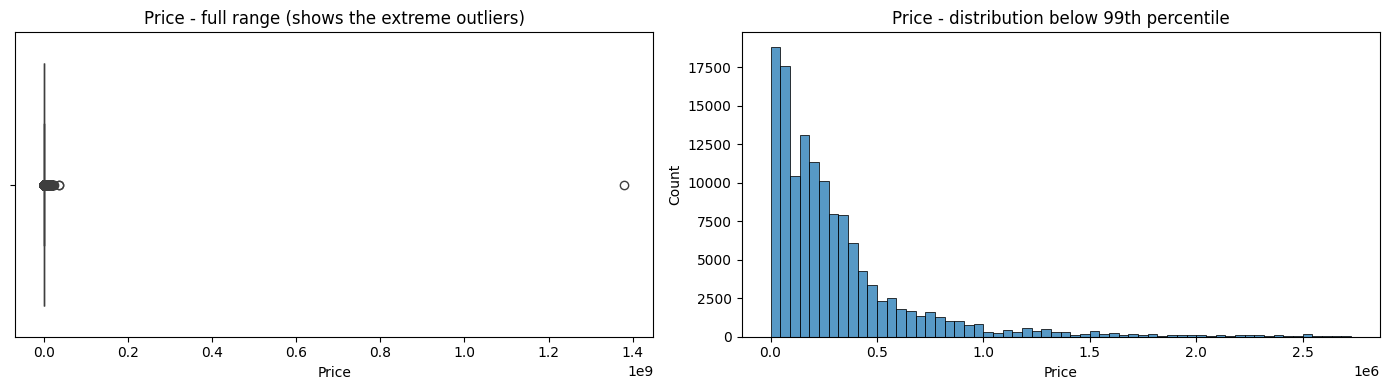

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x=price, ax=ax[0])
ax[0].set_title('Price - full range (shows the extreme outliers)')
sns.histplot(price[price < price.quantile(0.99)], bins=60, ax=ax[1])
ax[1].set_title('Price - distribution below 99th percentile')
plt.tight_layout(); plt.show()

**Conclusion:** The distribution is strongly right-skewed: most listings fall below ~500 000 €, with a long tail of high-value properties and at least one clearly corrupt value (~1.38 billion €) visible inthe boxplot. The realistic price range only becomes readable once the extreme outliers are set aside. These extreme values will be addressed later during the data preprocessing phase, and the skew suggests a log transform of the target is worth testing.

## <font color='#2f94d7' size=6>**5.9 Data Quality & Impossible Values**</font> <a class="anchor" id="5_9"></a>

[Back to TOC](#toc)

The raw `describe()` showed a minimum Price of 1€, a max of 1.38 **billion**€, and **negative areas** (GrossArea min −7, TotalArea min −7.2 million). These are corrupt records, not statistical outliers.

In [32]:
checks = {
    'Price <= 0'                 : df_train['Price'] <= 0,
    'Price == 1'                 : df_train['Price'] == 1,
    'GrossArea < 0'              : df_train['GrossArea'] < 0,
    'TotalArea < 0'              : df_train['TotalArea'] < 0,
    'LivingArea < 0'             : df_train['LivingArea'] < 0,
    'BuiltArea < 0'              : df_train['BuiltArea'] < 0,
    'LotSize < 0'                : df_train['LotSize'] < 0,
    'ConstructionYear > 2026'    : df_train['ConstructionYear'] > 2026,
    'ConstructionYear < 1800'    : df_train['ConstructionYear'] < 1800,
}
for name, mask in checks.items():
    print(f'{name:28s}: {int(mask.fillna(False).sum()):>7d}')

Price <= 0                  :       0
Price == 1                  :       1
GrossArea < 0               :       2
TotalArea < 0               :       7
LivingArea < 0              :       0
BuiltArea < 0               :       1
LotSize < 0                 :       0
ConstructionYear > 2026     :       0
ConstructionYear < 1800     :       0


In [33]:
checks = {
    # Impossible: logically cannot be true
    'Price <= 0'                 : df_train['Price'] <= 0,
    'GrossArea < 0'              : df_train['GrossArea'] < 0,
    'TotalArea < 0'              : df_train['TotalArea'] < 0,
    'LivingArea < 0'             : df_train['LivingArea'] < 0,
    'BuiltArea < 0'              : df_train['BuiltArea'] < 0,
    'LotSize < 0'                : df_train['LotSize'] < 0,
    'NumberOfWC < 0'             : df_train['NumberOfWC'] < 0,
    'NumberOfBathrooms < 0'      : df_train['NumberOfBathrooms'] < 0,
    'NumberOfBedrooms < 0'       : df_train['NumberOfBedrooms'] < 0,
    'TotalRooms < 0'             : df_train['TotalRooms'] < 0,
    'Parking < 0'                : df_train['Parking'] < 0,
    'ConstructionYear > 2026'    : df_train['ConstructionYear'] > 2026,
    'ConstructionYear < 1800'    : df_train['ConstructionYear'] < 1800,

    # Implausible: almost certainly corrupt (thresholds to tune later)
    'Price == 1'                 : df_train['Price'] == 1,
    'NumberOfBedrooms > 20'      : df_train['NumberOfBedrooms'] > 20,
    'NumberOfBathrooms > 20'     : df_train['NumberOfBathrooms'] > 20,
    'NumberOfWC > 20'            : df_train['NumberOfWC'] > 20,
    'TotalRooms > 50'            : df_train['TotalRooms'] > 50,
}

for name, mask in checks.items():
    print(f'{name:28s}: {int(mask.fillna(False).sum()):>7d}')

Price <= 0                  :       0
GrossArea < 0               :       2
TotalArea < 0               :       7
LivingArea < 0              :       0
BuiltArea < 0               :       1
LotSize < 0                 :       0
NumberOfWC < 0              :       1
NumberOfBathrooms < 0       :       3
NumberOfBedrooms < 0        :       0
TotalRooms < 0              :       0
Parking < 0                 :       0
ConstructionYear > 2026     :       0
ConstructionYear < 1800     :       0
Price == 1                  :       1
NumberOfBedrooms > 20       :      63
NumberOfBathrooms > 20      :      42
NumberOfWC > 20             :       8
TotalRooms > 50             :      22


### <font color='#2f94d7' size=6>**5.9.1 Investigating the extreme values further**</font> <a class="anchor" id="5_9_1"></a>

[Back to TOC](#toc)

In [34]:
big = df_train[(df_train['NumberOfBedrooms'] > 20) |
               (df_train['NumberOfBathrooms'] > 20) |
               (df_train['TotalRooms'] > 50)]
print('Rows flagged:', len(big))
print(big['Type'].value_counts())
big[['Type','Price','TotalRooms','NumberOfBedrooms','NumberOfBathrooms','GrossArea']].sort_values(
    'TotalRooms', ascending=False).head(20)

Rows flagged: 93
Type
Building               29
Hotel                  22
Farm                    8
House                   8
Other - Commercial      7
Land                    7
Investment              4
Manor                   2
Other - Residential     2
Apartment               2
Warehouse               1
Garage                  1
Name: count, dtype: int64


,Type,Price,TotalRooms,NumberOfBedrooms,NumberOfBathrooms,GrossArea
87191,House,56000.0,2751.0,1.0,0.0,NaN
118159,Garage,750000.0,100.0,NaN,NaN,NaN
128792,Building,950000.0,100.0,NaN,0.0,NaN
126043,Hotel,6800000.0,97.0,21.0,90.0,NaN
86144,Hotel,6800000.0,97.0,21.0,90.0,NaN
102893,Other - Commercial,1900000.0,80.0,NaN,77.0,NaN
120371,Other - Commercial,1900000.0,80.0,NaN,77.0,NaN
135015,Building,6900000.0,70.0,21.0,30.0,NaN
113904,Hotel,4500000.0,70.0,21.0,NaN,NaN
120217,Hotel,NaN,67.0,NaN,0.0,NaN


Consolidating all threshold checks from the EDA into two tiers:

- **Impossible** (negative/invalid, logically cannot be true): negative areas
  (`TotalArea`: 7, `GrossArea`: 2, `BuiltArea`: 1), negative room counts
  (`NumberOfBathrooms`: 3, `NumberOfWC`: 1). Rare but must be corrected.
- **Implausible** (extreme but not impossible): `NumberOfBedrooms > 20` (63),
  `NumberOfBathrooms > 20` (42), `TotalRooms > 50` (22), `NumberOfWC > 20` (8),
  `Price == 1` (1).

The 93 flagged rows (mostly `Building`, `Hotel`, `Farm`) show suspicious patterns,
duplicate exact values across unrelated listings and missing `GrossArea`, pointing
to data entry/scraping errors rather than genuine large properties. Supports
removing or capping at the cleaning stage.

## <font color='#2f94d7' size=6>**5.10 Temporal Analysis (PublishDate)**</font> <a class="anchor" id="5_10"></a>

[Back to TOC](#toc)

Listings with a valid date: 28779 (21.2%)
Date range: 2018-04-09 05:48:21.907000 -> 2025-01-28 19:07:18.900000


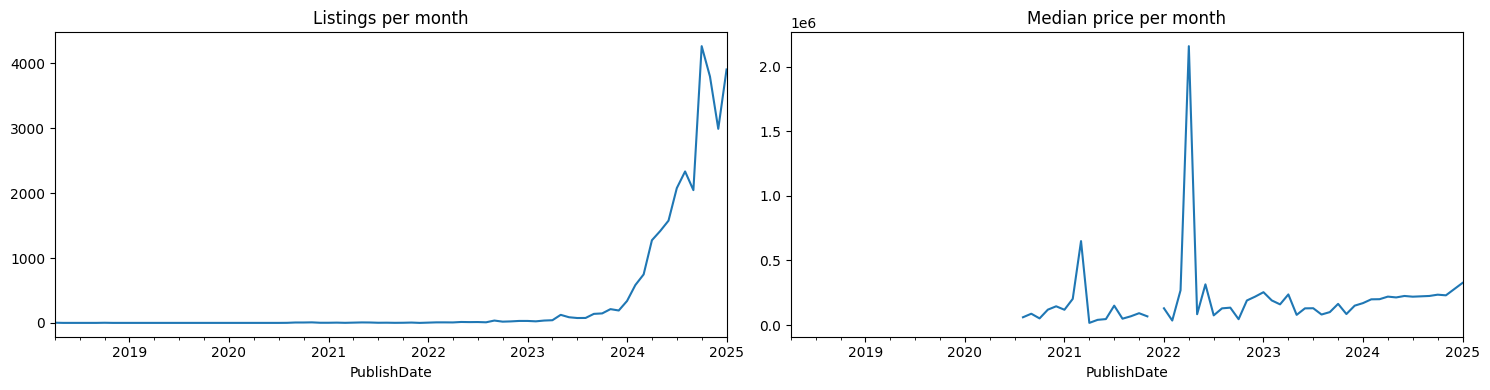

In [36]:
dated = df_train.dropna(subset=['PublishDate']).copy()
date_pattern = re.compile(r'^\d{4}-\d{2}-\d{2}')
dated = dated[dated['PublishDate'].astype(str).str.match(date_pattern)]
dated['PublishDate'] = pd.to_datetime(dated['PublishDate'], format='%Y-%m-%d %H:%M:%S.%f', errors='coerce')
dated = dated.dropna(subset=['PublishDate'])

print('Listings with a valid date:', len(dated), f'({len(dated)/len(df_train)*100:.1f}%)')
print('Date range:', dated['PublishDate'].min(), '->', dated['PublishDate'].max())

monthly = (dated.set_index('PublishDate')
                .resample('ME')
                .agg(n=('Price', 'size'), median_price=('Price', 'median')))

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
monthly['n'].plot(ax=ax[0], title='Listings per month')
monthly['median_price'].plot(ax=ax[1], title='Median price per month')
plt.tight_layout(); plt.show()

**Conclusion:** Restricting to the 28,779 rows (21.2%) with a valid, parseable date
(format `YYYY-MM-DD HH:MM:SS.ffffff`), the data spans 2018-04-09 to 2025-01-28.
"Listings per month" shows near-zero volume until 2023, then a sharp rise into
2024–2025, this looks like scraping volume growth (the data source capturing more
listings over time), not real market activity, so `PublishDate` behaves like a
capture timestamp rather than a true publication date. "Median price per month" is
noisy before 2023 (few data points, isolated spikes like 2021–2022) but more stable
afterward, with a mild upward trend in the recent period.

**Implications:**
- (1) `PublishDate` can give a rough sense of recent price trends, but shouldn't be
  treated as a reliable historical timeline before ~2023 due to sparse early
  coverage.
- (2) Listing volume trends reflect data collection, not market demand, so they
  shouldn't be used as a proxy for market activity.

## <font color='#2f94d7' size=6>**5.11 Relationships between variables**</font> <a class="anchor" id="5_11"></a>

[Back to TOC](#toc)

Rows in sane subset: 132544 (97.8%)


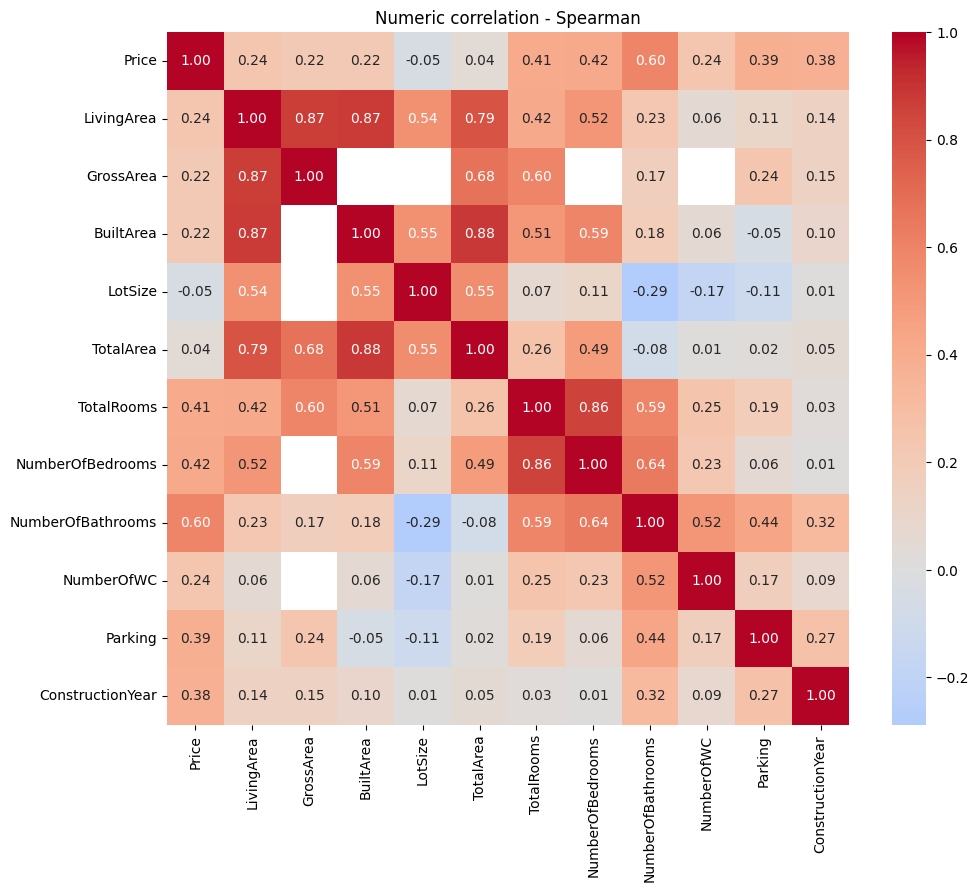

In [37]:
# Realistic price band: drops the corrupt extremes so relationships are clearer
lo, hi = df_train['Price'].quantile([0.01, 0.99])
sane = df_train['Price'].between(lo, hi)
print('Rows in sane subset:', int(sane.sum()), f'({sane.mean()*100:.1f}%)')

# Only the genuinely numeric columns (Floor & EnergyEfficiencyLevel are categorical now)
num = ['Price','LivingArea','GrossArea','BuiltArea','LotSize','TotalArea',
       'TotalRooms','NumberOfBedrooms','NumberOfBathrooms','NumberOfWC',
       'Parking','ConstructionYear']

# Spearman: robust to the area outliers still present and to non-linear relationships
corr = df_train.loc[sane, num].corr(method='spearman', numeric_only=True)
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Numeric correlation - Spearman'); plt.show()

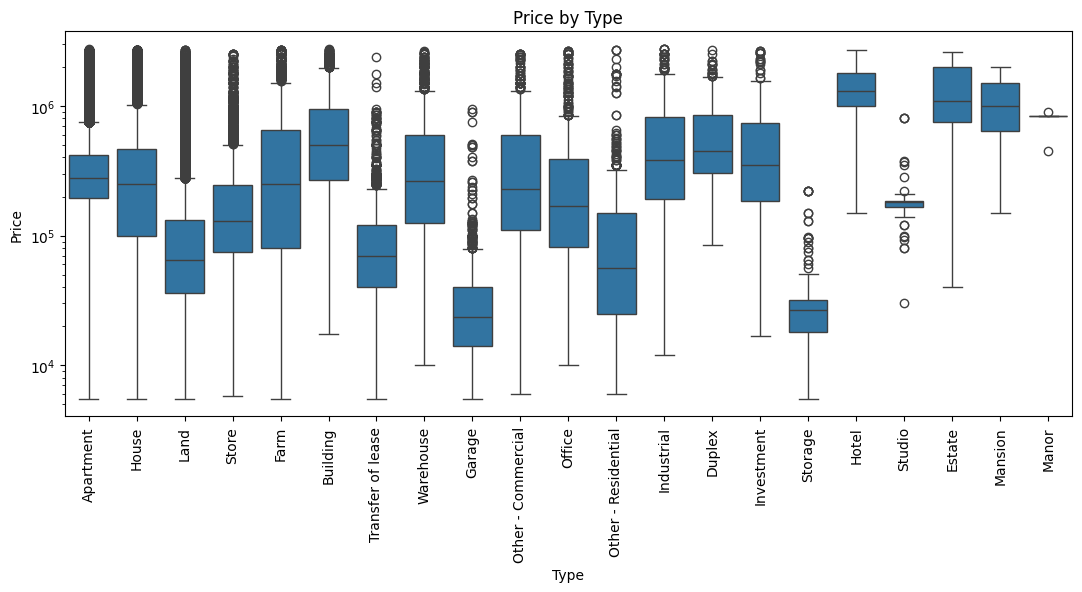

In [38]:
# Price by Type (log axis so the skew doesn't squash the boxes)
order = df_train['Type'].value_counts().index
plt.figure(figsize=(13, 5))
sns.boxplot(data=df_train[sane], x='Type', y='Price', order=order)
plt.yscale('log')
plt.xticks(rotation=90); plt.title('Price by Type'); plt.show()

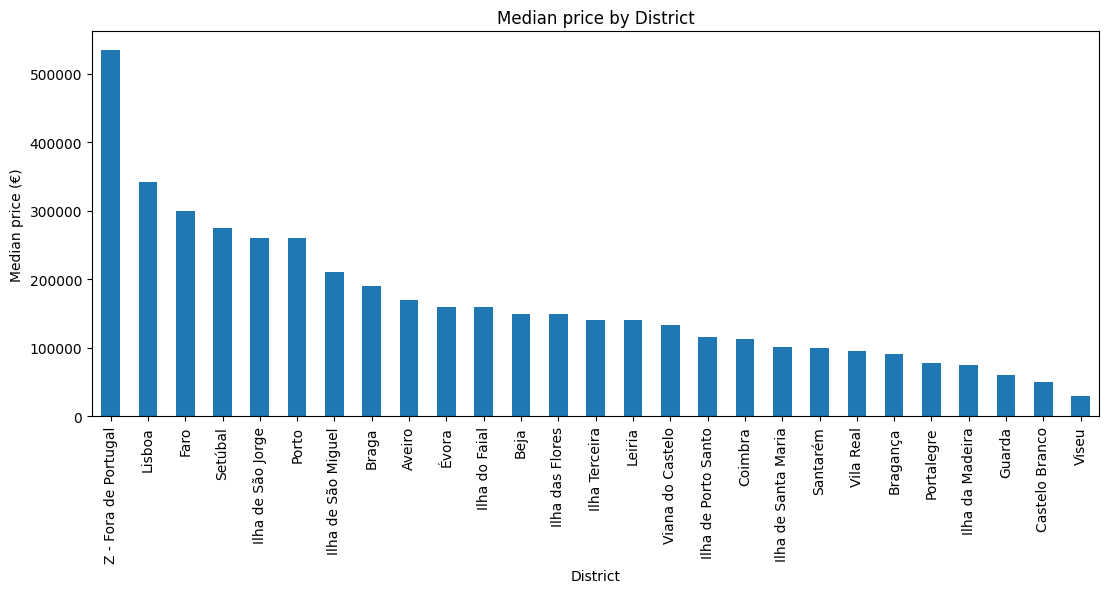

In [39]:
# Median price by District
med = df_train[sane].groupby('District')['Price'].median().sort_values(ascending=False)
med.plot.bar(figsize=(13, 5))
plt.ylabel('Median price (€)'); plt.title('Median price by District'); plt.show()

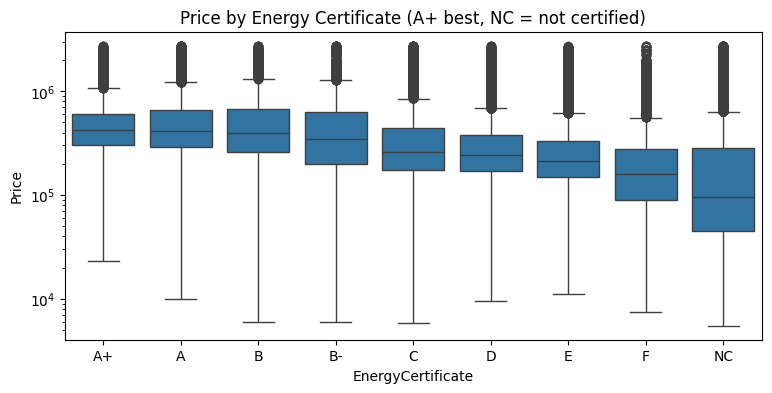

In [40]:
# Price by energy rating — use EnergyCertificate (letters), ordered best -> worst, NC last
order_e = [g for g in ['A+','A','B','B-','C','D','E','F','NC']
           if g in set(df_train['EnergyCertificate'].dropna())]
plt.figure(figsize=(9, 4))
sns.boxplot(data=df_train[sane], x='EnergyCertificate', y='Price', order=order_e)
plt.yscale('log')
plt.title('Price by Energy Certificate (A+ best, NC = not certified)'); plt.show()

**Conclusion:**

`Price` correlates more with room/bathroom counts (Bathrooms 0.60, Bedrooms/Rooms
0.42) than with area, area's signal is weakened by missingness and by pooling all
property types. The 5 area columns are highly redundant (0.79–0.88), so one
(`LivingArea`, best-populated) suffices.

- **Type**: spans Hotels/Estates (~€1M+) to Garages/Storage (~€25k) — cheap
  listings are real, not errors.
- **District**: clear coastal-vs-interior gradient (note: top bar is `'Z - Fora
  de Portugal'`, not a real district — exclude when reading the pattern).
- **EnergyCertificate**: monotonic with price (A+ high, NC low), but partly
  confounded with `Type`.

These results will inform feature selection, which variables are redundant, and
which to keep.

## <font color='#2f94d7' size=6>**5.12 Categorical Association - Cramér's V**</font> <a class="anchor" id="5_12"></a>

[Back to TOC](#toc)

The Spearman heatmap above only covers numeric features. To measure association between the
**categorical** variables we use Cramér's V, which ranges from 0 (independent) to 1 (perfectly
associated). Unlike correlation it has no direction or sign, it only quantifies how strongly
two categoricals move together.

Two methodological choices:

- **Bias-corrected version.** Plain Cramér's V is inflated when the variables have very
  different numbers of categories (our booleans have 2, District has 27), making high-cardinality
  pairs look artificially strong. The bias-corrected (Bergsma) formula removes that distortion.
- **Low-cardinality columns only.** We exclude City (275) and Town (2 263): their contingency
  tables are huge and slow, and Cramér's V becomes unreliable and inflated with that many sparse
  categories. We keep Type, EnergyCertificate, ConservationStatus, District and the boolean
  amenities.

Each pair is computed only on rows where both columns are present, so pairs involving heavily
missing columns (e.g. ConservationStatus) rest on a smaller subset and should be read with care.
We use this to spot redundant categoricals and to quantify confounding between Type, location and the other categories.

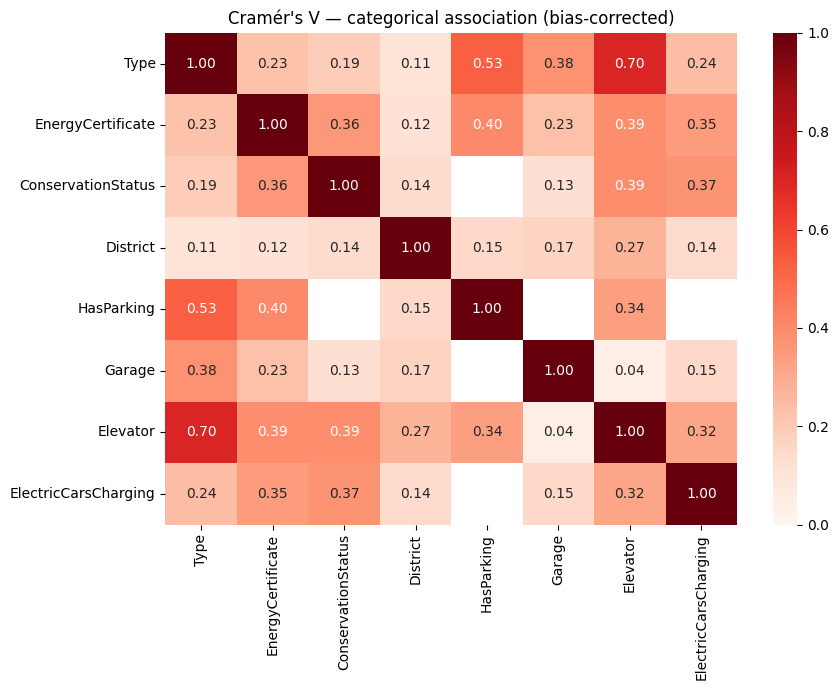

In [41]:
def cramers_v(x, y):
    """Bias-corrected Cramér's V. Uses only rows where both are non-null."""
    cm = pd.crosstab(x, y)
    if cm.shape[0] < 2 or cm.shape[1] < 2:
        return np.nan
    chi2 = chi2_contingency(cm)[0]
    n = cm.to_numpy().sum()
    if n == 0:
        return np.nan
    phi2 = chi2 / n
    r, k = cm.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(kcorr - 1, rcorr - 1)
    if denom <= 0:
        return np.nan
    return np.sqrt(phi2corr / denom)

cat_cols = ['Type', 'EnergyCertificate', 'ConservationStatus', 'District',
            'HasParking', 'Garage', 'Elevator', 'ElectricCarsCharging']

cv = pd.DataFrame(np.eye(len(cat_cols)), index=cat_cols, columns=cat_cols)
for i, a in enumerate(cat_cols):
    for b in cat_cols[i + 1:]:
        v = cramers_v(df_train[a], df_train[b])
        cv.loc[a, b] = cv.loc[b, a] = v

plt.figure(figsize=(9, 7))
sns.heatmap(cv.astype(float), annot=True, fmt='.2f', cmap='Reds', vmin=0, vmax=1)
plt.title("Cramér's V — categorical association (bias-corrected)")
plt.tight_layout(); plt.show()

**Conclusion:**

- **`Type` -`Elevator` (0.70)** is the strongest pair. It makes sense, since
  elevators are near-exclusive to `Apartment`/`Building`, not `Land`/`House`.
- **`Type` - `HasParking` (0.53)** is also strong, for the same structural reason.
- **`Garage` -`Elevator` (0.04)** is essentially independent, having one says
  nothing about the other, despite both being "amenity" booleans.
- **`District`** has the weakest associations with everything (0.11–0.27),
  location doesn't strongly determine these features, unlike `Type`.
- **Missing cells** (`HasParking`/`Garage`, `HasParking`/`ElectricCarsCharging`)
  reflect the earlier finding: these columns barely overlap in non-null rows
  (two complementary sources), so their association can't be computed.

Overall, `Type` is the main driver of association among the boolean amenities,
reinforcing that `Type` should be treated as a key feature, not just a label.